# Introducción al proyecto

## Contexto comercial

La entidad financiera opera en un entorno digital donde millones de transacciones se procesan diariamente a través de canales online, cajeros y sucursales. En este contexto, el fraude bancario representa un riesgo económico y reputacional significativo: cargos no autorizados, cuentas comprometidas y redes organizadas de fraude pueden generar pérdidas directas, aumentar costos operativos y erosionar la confianza del cliente. Para proteger activos y optimizar la experiencia del cliente, la organización necesita pasar de respuestas reactivas a detecciones proactivas basadas en datos. En lugar de depender únicamente de reglas manuales y listas negras, la compañía busca un enfoque de Machine Learning que identifique patrones sutiles y emergentes en el comportamiento transaccional para bloquear o marcar transacciones sospechosas en tiempo real.

## Problema comercial
¿Qué señales y combinaciones de variables permiten identificar transacciones fraudulentas con alta precisión, y cómo podemos predecirlas de forma confiable para minimizar pérdidas y falsos positivos?

## Contexto analítico
El equipo de datos ha entregado un conjunto estructurado que contiene 18 variables por transacción y por cuenta, incluyendo: identificadores de cuenta y dispositivo, monto de la transacción, timestamp, canal (online/ATM/sucursal), geolocalización, IP anonimizada, historial de transacciones, intentos de login, balance de cuenta y métricas de comportamiento agregadas. Para abordar el problema se empleará un modelo supervisado de Machine Learning; XGBoost se propone como algoritmo principal por su robustez en datos tabulares, su capacidad para capturar interacciones no lineales y su eficiencia en escenarios desbalanceados.

## Objetivo general

Desarrollar un sistema de clasificación que prediga si una transacción es fraudulenta o legítima usando las características disponibles, con un pipeline reproducible que incluya limpieza, generación de features temporales y de red, entrenamiento y evaluación robusta (validación temporal y métricas orientadas a negocio). El objetivo es maximizar la detección temprana de fraudes manteniendo un nivel aceptable de falsos positivos, de modo que las decisiones automáticas y los flujos de revisión humana reduzcan pérdidas y mejoren la eficiencia operativa.


In [1]:


#IMPORTACION DE LIBRERIAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import xgboost as xgb
import os
import hashlib
import requests
import plotly.express as px
import plotly.graph_objects as go

## EDA

In [2]:
# Cargar datos de transacciones
df = pd.read_csv('../data/transacciones_banco.csv')
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [4]:
# INFORME DE CALIDAD DE DATOS

print("INFORME DE CALIDAD DE DATOS")

# DIMENSIONES
print("\nDIMENSIONES DEL DATASET")
print("-"*70)
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]} | Total datos: {df.shape[0] * df.shape[1]:,}")

# TIPOS DE DATOS
print(f"\nTIPOS DE DATOS")
print("-"*70)
tipos = df.dtypes.value_counts()
for tipo, cantidad in tipos.items():
    print(f"{tipo}: {cantidad} columnas")

# VALORES NULOS
print(f"\nVALORES NULOS")
print("-"*70)
total_nulos = df.isnull().sum().sum()
cols_con_nulos = (df.isnull().sum() > 0).sum()
print(f"Total de valores nulos: {total_nulos:,}")
print(f"Columnas con nulos: {cols_con_nulos} de {df.shape[1]}")
if cols_con_nulos > 0:
    nulos = df.isnull().sum()[df.isnull().sum() > 0]
    for columna, cantidad in nulos.items():
        print(f"  - {columna}: {cantidad:,}")

# REGISTROS DUPLICADOS
print(f"\nREGISTROS DUPLICADOS")
print("-"*70)
duplicados = df.duplicated().sum()
pct_dup = (duplicados/len(df))*100
print(f"Registros duplicados: {duplicados}")
print(f"Registros únicos: {len(df) - duplicados:,}")


INFORME DE CALIDAD DE DATOS

DIMENSIONES DEL DATASET
----------------------------------------------------------------------
Filas: 2,512 | Columnas: 16 | Total datos: 40,192

TIPOS DE DATOS
----------------------------------------------------------------------
object: 11 columnas
int64: 3 columnas
float64: 2 columnas

VALORES NULOS
----------------------------------------------------------------------
Total de valores nulos: 0
Columnas con nulos: 0 de 16

REGISTROS DUPLICADOS
----------------------------------------------------------------------
Registros duplicados: 0
Registros únicos: 2,512


In [5]:
# CONVERTIR COLUMNAS DE FECHA A TIPO DATETIME
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], dayfirst=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionID            2512 non-null   object        
 1   AccountID                2512 non-null   object        
 2   TransactionAmount        2512 non-null   float64       
 3   TransactionDate          2512 non-null   datetime64[ns]
 4   TransactionType          2512 non-null   object        
 5   Location                 2512 non-null   object        
 6   DeviceID                 2512 non-null   object        
 7   IP Address               2512 non-null   object        
 8   MerchantID               2512 non-null   object        
 9   Channel                  2512 non-null   object        
 10  CustomerAge              2512 non-null   int64         
 11  CustomerOccupation       2512 non-null   object        
 12  TransactionDuration      2512 non-

In [6]:
# Renombrar columna 'IP Address' a 'ip_address'
df = df.rename(columns={'IP Address': 'ip_address'})

In [7]:
# Eliminar columnas innecesarias manteniendo 'Location'
# Reaplicar eliminación de columnas manejando nombres alternativos
cols_to_drop = ['TransactionID', 'AccountID', 'DeviceID', 'MerchantID', 'PreviousTransactionDate', 'ip_hash']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], axis=1)

df.head(30)

,TransactionAmount,TransactionDate,TransactionType,Location,ip_address,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,2023-04-11 16:29:14,Debit,San Diego,162.198.218.92,ATM,70,Doctor,81,1,5112.21
1,376.24,2023-06-27 16:44:19,Debit,Houston,13.149.61.4,ATM,68,Doctor,141,1,13758.91
2,126.29,2023-07-10 18:16:08,Debit,Mesa,215.97.143.157,Online,19,Student,56,1,1122.35
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,200.13.225.150,Online,26,Student,25,1,8569.06
4,13.45,2023-10-16 17:51:24,Credit,Atlanta,65.164.3.100,Online,26,Student,198,1,7429.40
5,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,117.67.192.211,ATM,18,Student,172,1,781.68
6,7.08,2023-02-15 16:36:48,Credit,Seattle,140.212.253.222,ATM,37,Doctor,139,1,13316.71
7,171.42,2023-05-08 17:47:59,Credit,Indianapolis,92.214.76.157,Branch,67,Retired,291,1,2796.24
8,106.23,2023-03-21 16:59:46,Credit,Detroit,24.148.92.177,Branch,51,Engineer,86,1,9095.14
9,815.96,2023-03-31 16:06:57,Debit,Nashville,32.169.88.41,ATM,55,Doctor,120,1,1021.88


### 1. Distribución del monto de las transacciones

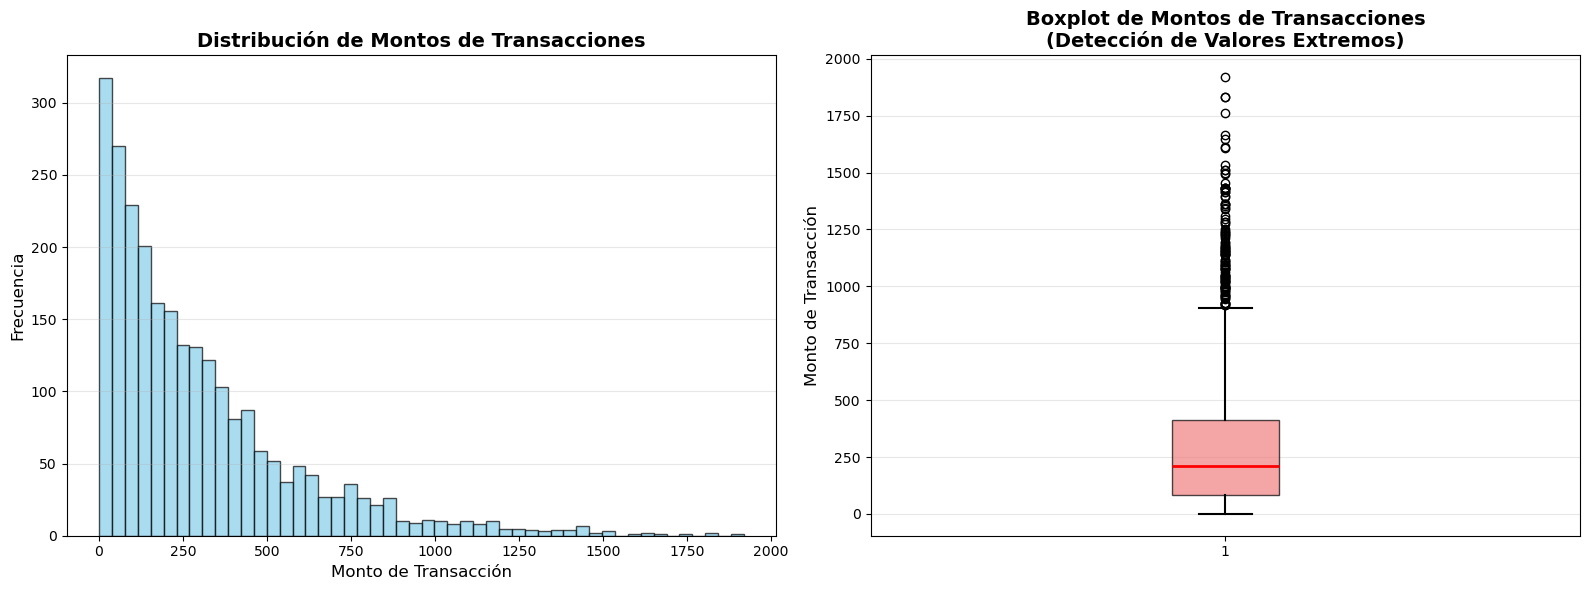

ESTADÍSTICAS DE LOS MONTOS DE TRANSACCIONES
count    2512.000000
mean      297.593778
std       291.946243
min         0.260000
25%        81.885000
50%       211.140000
75%       414.527500
max      1919.110000
Name: TransactionAmount, dtype: float64

Valor Mínimo: $0.26
Valor Máximo: $1919.11
Rango: $1918.85


In [8]:
# Análisis de distribución del monto de transacciones
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma
axes[0].hist(df['TransactionAmount'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Monto de Transacción', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Montos de Transacciones', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Boxplot
axes[1].boxplot(df['TransactionAmount'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightcoral', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='black', linewidth=1.5),
                capprops=dict(color='black', linewidth=1.5))
axes[1].set_ylabel('Monto de Transacción', fontsize=12)
axes[1].set_title('Boxplot de Montos de Transacciones\n(Detección de Valores Extremos)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print("=" * 60)
print("ESTADÍSTICAS DE LOS MONTOS DE TRANSACCIONES")
print("=" * 60)
print(df['TransactionAmount'].describe())
print(f"\nValor Mínimo: ${df['TransactionAmount'].min():.2f}")
print(f"Valor Máximo: ${df['TransactionAmount'].max():.2f}")
print(f"Rango: ${df['TransactionAmount'].max() - df['TransactionAmount'].min():.2f}")

### 2. Análisis temporal de transacciones

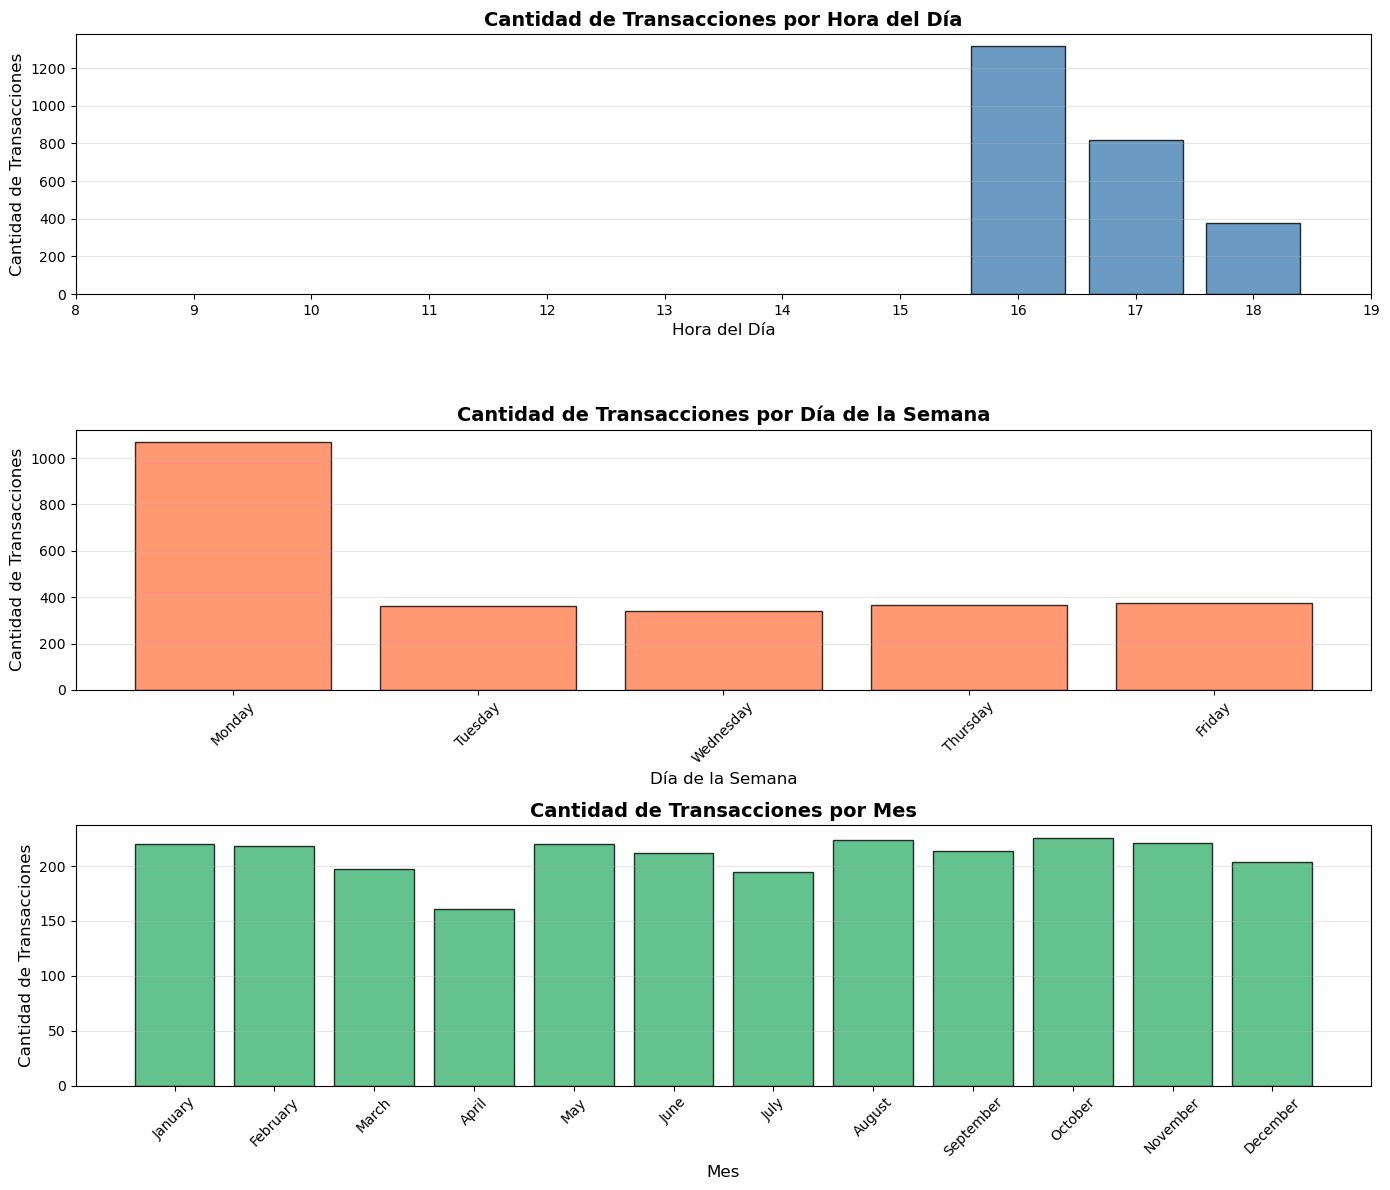

PATRONES TEMPORALES

Hora con más transacciones: 16:00 hrs (1,316 transacciones)
Hora con menos transacciones: 18:00 hrs (377 transacciones)

Día con más transacciones: Monday (1,070.0 transacciones)
Día con menos transacciones: Wednesday (341.0 transacciones)

Mes con más transacciones: October (226 transacciones)
Mes con menos transacciones: April (161 transacciones)


In [9]:
# Análisis temporal de transacciones
# Extraer componentes temporales
df['hour'] = df['TransactionDate'].dt.hour
df['day_of_week'] = df['TransactionDate'].dt.day_name()
df['month'] = df['TransactionDate'].dt.month_name()

# Crear subgráficos
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. Transacciones por Hora
hour_counts = df['hour'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Hora del Día', fontsize=12)
axes[0].set_ylabel('Cantidad de Transacciones', fontsize=12)
axes[0].set_title('Cantidad de Transacciones por Hora del Día', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(8,20))
axes[0].grid(axis='y', alpha=0.3)

# 2. Transacciones por Día de la Semana
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order)
axes[1].bar(day_counts.index, day_counts.values, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Día de la Semana', fontsize=12)
axes[1].set_ylabel('Cantidad de Transacciones', fontsize=12)
axes[1].set_title('Cantidad de Transacciones por Día de la Semana', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# 3. Transacciones por Mes
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
month_counts = df['month'].value_counts().reindex(month_order)
axes[2].bar(month_counts.index, month_counts.values, color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[2].set_xlabel('Mes', fontsize=12)
axes[2].set_ylabel('Cantidad de Transacciones', fontsize=12)
axes[2].set_title('Cantidad de Transacciones por Mes', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas adicionales
print("=" * 60)
print("PATRONES TEMPORALES")
print("=" * 60)
print(f"\nHora con más transacciones: {hour_counts.idxmax()}:00 hrs ({hour_counts.max():,} transacciones)")
print(f"Hora con menos transacciones: {hour_counts.idxmin()}:00 hrs ({hour_counts.min():,} transacciones)")
print(f"\nDía con más transacciones: {day_counts.idxmax()} ({day_counts.max():,} transacciones)")
print(f"Día con menos transacciones: {day_counts.idxmin()} ({day_counts.min():,} transacciones)")
print(f"\nMes con más transacciones: {month_counts.idxmax()} ({month_counts.max():,} transacciones)")
print(f"Mes con menos transacciones: {month_counts.idxmin()} ({month_counts.min():,} transacciones)")

### 3. Relación entre edad del cliente y monto de transacción

C:\Users\joako\AppData\Local\Temp\ipykernel_11404\2314076864.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_age, labels=age_groups_order, patch_artist=True,


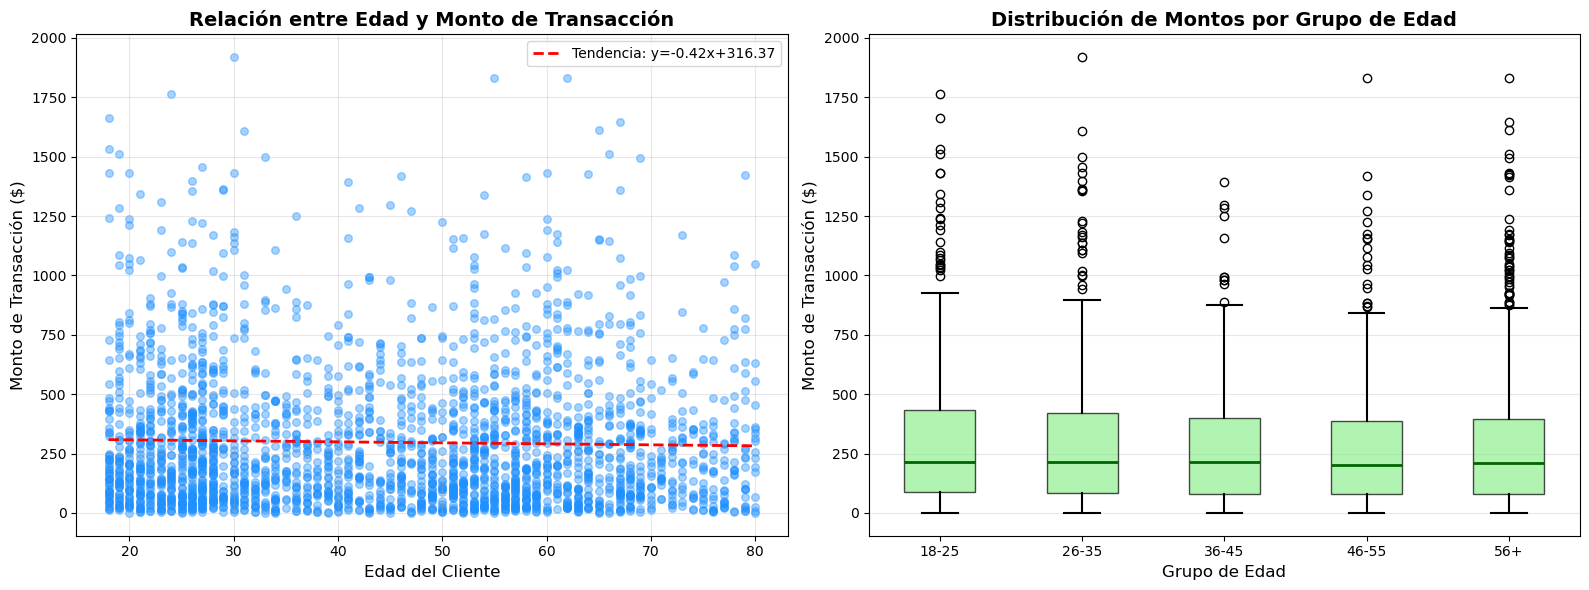

ANÁLISIS DE MONTOS POR GRUPO DE EDAD

Grupo 18-25:
  Cantidad de transacciones: 475
  Monto promedio: $315.90
  Monto mediano: $213.25
  Monto mínimo: $0.26
  Monto máximo: $1762.28

Grupo 26-35:
  Cantidad de transacciones: 486
  Monto promedio: $308.13
  Monto mediano: $215.16
  Monto mínimo: $0.45
  Monto máximo: $1919.11

Grupo 36-45:
  Cantidad de transacciones: 303
  Monto promedio: $281.50
  Monto mediano: $215.90
  Monto mínimo: $0.32
  Monto máximo: $1392.54

Grupo 46-55:
  Cantidad de transacciones: 432
  Monto promedio: $274.08
  Monto mediano: $203.88
  Monto mínimo: $0.84
  Monto máximo: $1830.00

Grupo 56+:
  Cantidad de transacciones: 816
  Monto promedio: $299.08
  Monto mediano: $211.14
  Monto mínimo: $1.82
  Monto máximo: $1831.02


In [10]:
# Análisis de relación entre edad y monto de transacción
# Crear rangos de edad para mejor visualización
df['age_group'] = pd.cut(df['CustomerAge'], 
                          bins=[0, 25, 35, 45, 55, 100], 
                          labels=['18-25', '26-35', '36-45', '46-55', '56+'])

# Crear figura con subgráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Scatter plot con línea de tendencia
axes[0].scatter(df['CustomerAge'], df['TransactionAmount'], alpha=0.4, color='dodgerblue', s=30)
# Calcular y graficar línea de tendencia
z = np.polyfit(df['CustomerAge'], df['TransactionAmount'], 1)
p = np.poly1d(z)
axes[0].plot(df['CustomerAge'].sort_values(), p(df['CustomerAge'].sort_values()), 
             "r--", linewidth=2, label=f'Tendencia: y={z[0]:.2f}x+{z[1]:.2f}')
axes[0].set_xlabel('Edad del Cliente', fontsize=12)
axes[0].set_ylabel('Monto de Transacción ($)', fontsize=12)
axes[0].set_title('Relación entre Edad y Monto de Transacción', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)

# 2. Boxplot por grupos de edad
age_groups_order = ['18-25', '26-35', '36-45', '46-55', '56+']
data_by_age = [df[df['age_group'] == group]['TransactionAmount'].values for group in age_groups_order]
bp = axes[1].boxplot(data_by_age, labels=age_groups_order, patch_artist=True,
                      boxprops=dict(facecolor='lightgreen', alpha=0.7),
                      medianprops=dict(color='darkgreen', linewidth=2),
                      whiskerprops=dict(color='black', linewidth=1.5),
                      capprops=dict(color='black', linewidth=1.5))
axes[1].set_xlabel('Grupo de Edad', fontsize=12)
axes[1].set_ylabel('Monto de Transacción ($)', fontsize=12)
axes[1].set_title('Distribución de Montos por Grupo de Edad', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas por grupo de edad
print("=" * 70)
print("ANÁLISIS DE MONTOS POR GRUPO DE EDAD")
print("=" * 70)
for group in age_groups_order:
    group_data = df[df['age_group'] == group]['TransactionAmount']
    print(f"\nGrupo {group}:")
    print(f"  Cantidad de transacciones: {len(group_data):,}")
    print(f"  Monto promedio: ${group_data.mean():.2f}")
    print(f"  Monto mediano: ${group_data.median():.2f}")
    print(f"  Monto mínimo: ${group_data.min():.2f}")
    print(f"  Monto máximo: ${group_data.max():.2f}")

### 4. Distribución de ocupaciones y relación con montos de transacción

C:\Users\joako\AppData\Local\Temp\ipykernel_11404\1911989251.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_occupation, labels=occupation_counts.index, patch_artist=True,


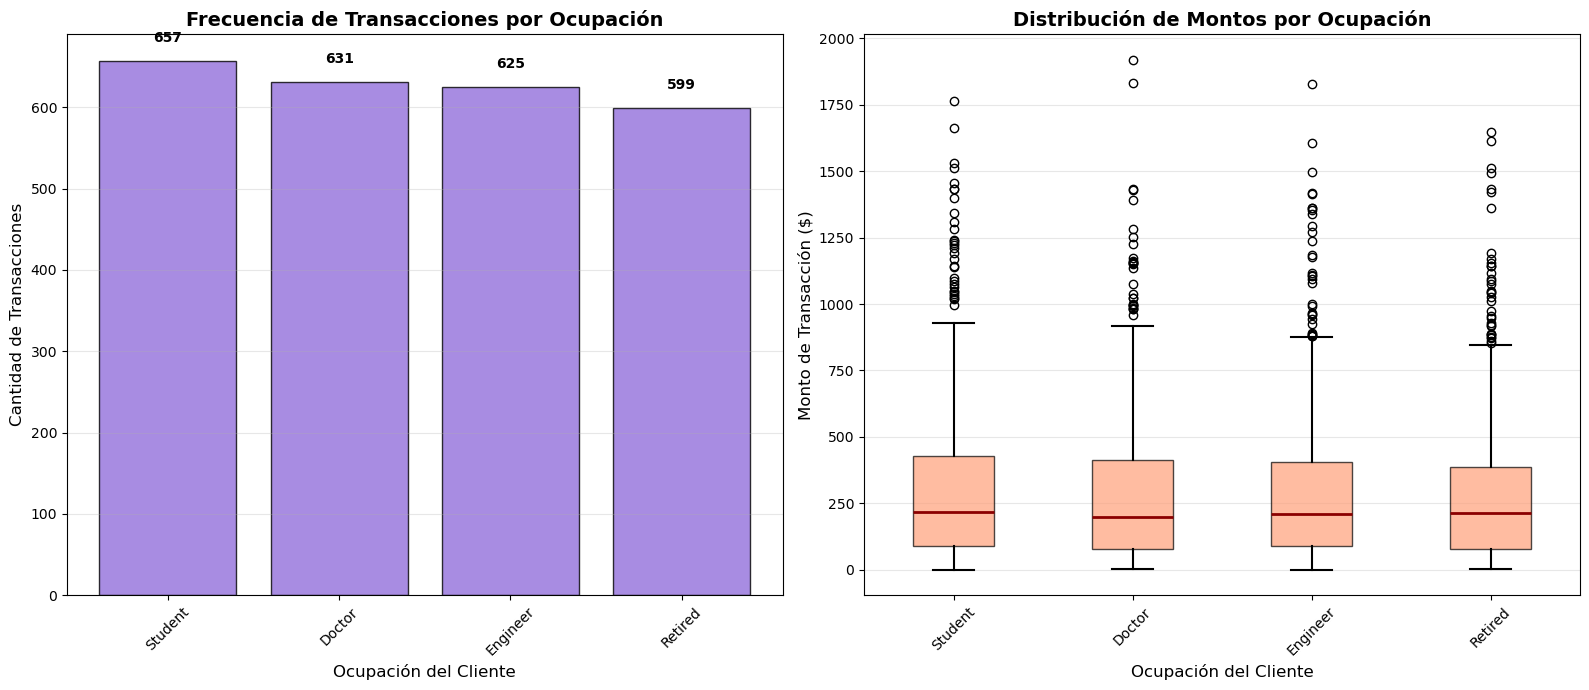

ANÁLISIS DETALLADO POR OCUPACIÓN

Student:
  Cantidad de transacciones: 657 (26.15% del total)
  Monto promedio: $313.22
  Monto mediano: $215.94
  Monto mínimo: $0.26
  Monto máximo: $1762.28
  Desviación estándar: $304.62

Doctor:
  Cantidad de transacciones: 631 (25.12% del total)
  Monto promedio: $292.70
  Monto mediano: $199.09
  Monto mínimo: $1.14
  Monto máximo: $1919.11
  Desviación estándar: $292.45

Engineer:
  Cantidad de transacciones: 625 (24.88% del total)
  Monto promedio: $289.04
  Monto mediano: $211.36
  Monto mínimo: $0.32
  Monto máximo: $1830.00
  Desviación estándar: $283.16

Retired:
  Cantidad de transacciones: 599 (23.85% del total)
  Monto promedio: $294.53
  Monto mediano: $213.33
  Monto mínimo: $1.21
  Monto máximo: $1647.74
  Desviación estándar: $286.27


In [11]:
# Análisis de ocupaciones y su relación con montos de transacción
# Crear figura con subgráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Frecuencia de transacciones por ocupación
occupation_counts = df['CustomerOccupation'].value_counts()
axes[0].bar(occupation_counts.index, occupation_counts.values, color='mediumpurple', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Ocupación del Cliente', fontsize=12)
axes[0].set_ylabel('Cantidad de Transacciones', fontsize=12)
axes[0].set_title('Frecuencia de Transacciones por Ocupación', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(occupation_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Boxplot de montos por ocupación
occupations = df['CustomerOccupation'].unique()
data_by_occupation = [df[df['CustomerOccupation'] == occ]['TransactionAmount'].values for occ in occupation_counts.index]
bp = axes[1].boxplot(data_by_occupation, labels=occupation_counts.index, patch_artist=True,
                      boxprops=dict(facecolor='lightsalmon', alpha=0.7),
                      medianprops=dict(color='darkred', linewidth=2),
                      whiskerprops=dict(color='black', linewidth=1.5),
                      capprops=dict(color='black', linewidth=1.5))
axes[1].set_xlabel('Ocupación del Cliente', fontsize=12)
axes[1].set_ylabel('Monto de Transacción ($)', fontsize=12)
axes[1].set_title('Distribución de Montos por Ocupación', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas detalladas por ocupación
print("=" * 80)
print("ANÁLISIS DETALLADO POR OCUPACIÓN")
print("=" * 80)
for occupation in occupation_counts.index:
    occ_data = df[df['CustomerOccupation'] == occupation]['TransactionAmount']
    print(f"\n{occupation}:")
    print(f"  Cantidad de transacciones: {len(occ_data):,} ({len(occ_data)/len(df)*100:.2f}% del total)")
    print(f"  Monto promedio: ${occ_data.mean():.2f}")
    print(f"  Monto mediano: ${occ_data.median():.2f}")
    print(f"  Monto mínimo: ${occ_data.min():.2f}")
    print(f"  Monto máximo: ${occ_data.max():.2f}")
    print(f"  Desviación estándar: ${occ_data.std():.2f}")

### 5. Análisis de intentos de login por ocupación

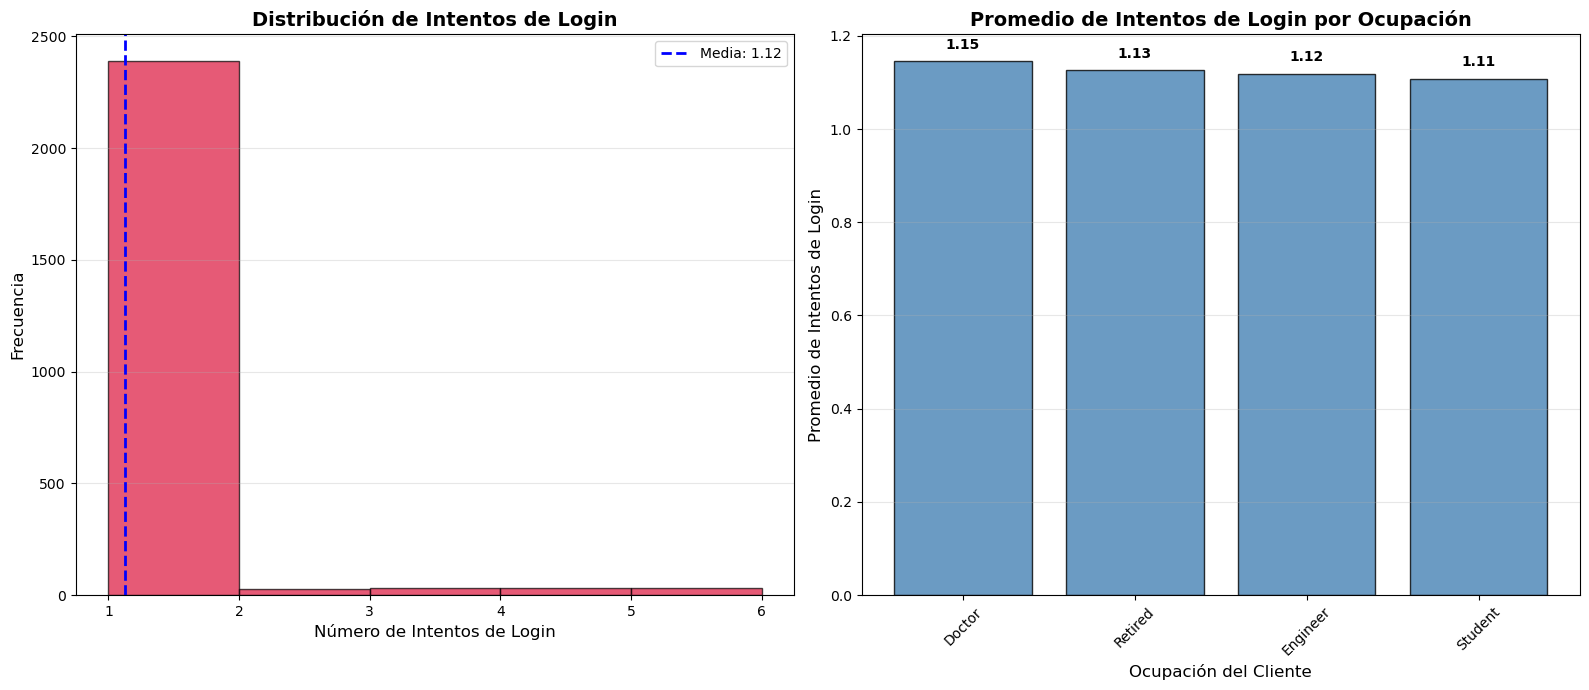

ANÁLISIS DE INTENTOS DE LOGIN POR OCUPACIÓN

Doctor:
  Promedio de intentos: 1.15
  Mediana de intentos: 1.00
  Máximo de intentos: 5
  Transacciones con >1 intento: 35 (5.55%)

Retired:
  Promedio de intentos: 1.13
  Mediana de intentos: 1.00
  Máximo de intentos: 5
  Transacciones con >1 intento: 27 (4.51%)

Engineer:
  Promedio de intentos: 1.12
  Mediana de intentos: 1.00
  Máximo de intentos: 5
  Transacciones con >1 intento: 31 (4.96%)

Student:
  Promedio de intentos: 1.11
  Mediana de intentos: 1.00
  Máximo de intentos: 5
  Transacciones con >1 intento: 29 (4.41%)

ANÁLISIS DE COMPORTAMIENTO SOSPECHOSO (MÚLTIPLES INTENTOS)

Total de transacciones con más de 1 intento de login: 122 (4.86%)

Distribución por ocupación:
  Doctor: 35 transacciones (5.55% de sus transacciones)
  Student: 29 transacciones (4.41% de sus transacciones)
  Retired: 27 transacciones (4.51% de sus transacciones)
  Engineer: 31 transacciones (4.96% de sus transacciones)


In [12]:
# Análisis de intentos de login y su relación con ocupación
# Crear figura con subgráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Histograma general de intentos de login
axes[0].hist(df['LoginAttempts'], bins=range(df['LoginAttempts'].min(), df['LoginAttempts'].max() + 2), 
             color='crimson', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Número de Intentos de Login', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Intentos de Login', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].axvline(df['LoginAttempts'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Media: {df["LoginAttempts"].mean():.2f}')
axes[0].legend()

# 2. Promedio de intentos de login por ocupación
occupation_login = df.groupby('CustomerOccupation')['LoginAttempts'].agg(['mean', 'max', 'count']).sort_values('mean', ascending=False)
axes[1].bar(occupation_login.index, occupation_login['mean'], color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Ocupación del Cliente', fontsize=12)
axes[1].set_ylabel('Promedio de Intentos de Login', fontsize=12)
axes[1].set_title('Promedio de Intentos de Login por Ocupación', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(occupation_login['mean'].values):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Estadísticas detalladas
print("=" * 80)
print("ANÁLISIS DE INTENTOS DE LOGIN POR OCUPACIÓN")
print("=" * 80)
for occupation in occupation_login.index:
    occ_data = df[df['CustomerOccupation'] == occupation]['LoginAttempts']
    print(f"\n{occupation}:")
    print(f"  Promedio de intentos: {occ_data.mean():.2f}")
    print(f"  Mediana de intentos: {occ_data.median():.2f}")
    print(f"  Máximo de intentos: {occ_data.max()}")
    print(f"  Transacciones con >1 intento: {(occ_data > 1).sum()} ({(occ_data > 1).sum()/len(occ_data)*100:.2f}%)")
    
# Análisis específico de comportamiento sospechoso
print("\n" + "=" * 80)
print("ANÁLISIS DE COMPORTAMIENTO SOSPECHOSO (MÚLTIPLES INTENTOS)")
print("=" * 80)
high_attempts = df[df['LoginAttempts'] > 1]
print(f"\nTotal de transacciones con más de 1 intento de login: {len(high_attempts)} ({len(high_attempts)/len(df)*100:.2f}%)")
print("\nDistribución por ocupación:")
for occupation in df['CustomerOccupation'].unique():
    occ_high = high_attempts[high_attempts['CustomerOccupation'] == occupation]
    total_occ = df[df['CustomerOccupation'] == occupation]
    print(f"  {occupation}: {len(occ_high)} transacciones ({len(occ_high)/len(total_occ)*100:.2f}% de sus transacciones)")


### 6. Distribución geográfica de clientes por provincia

Análisis de la distribución de clientes del banco por provincia. Este análisis permite identificar qué provincia tiene la mayor cantidad de personas/clientes registrados en el banco, independientemente del número de transacciones que realicen.

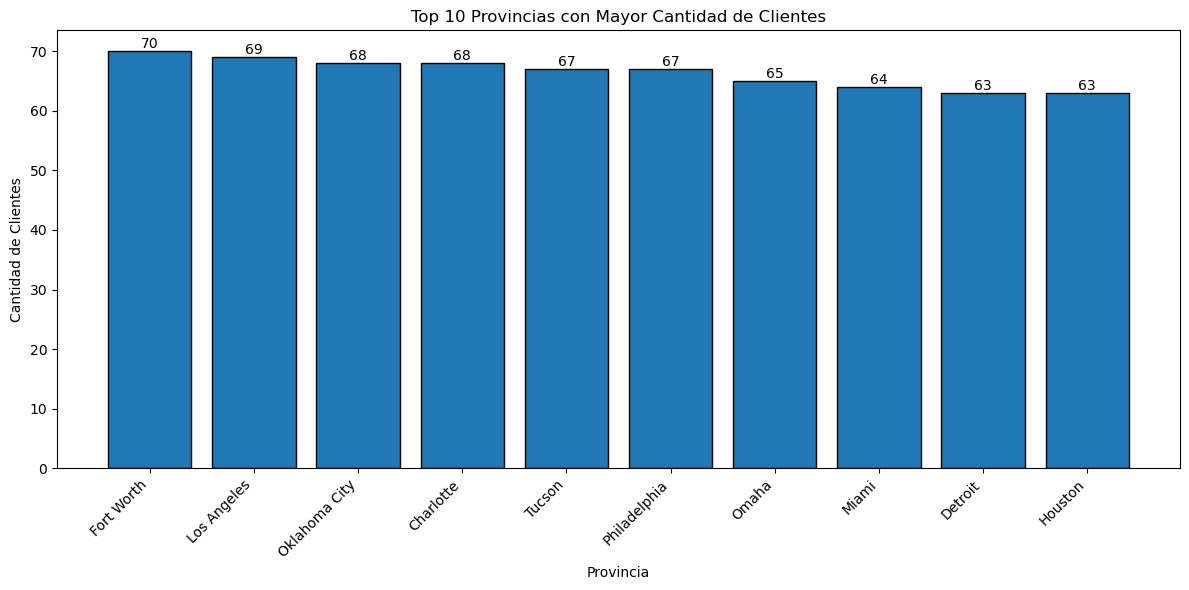

In [15]:
# Contar la cantidad de clientes por provincia (Top 10)
location_counts = df['Location'].value_counts().head(10)

# Crear el grafico de barras con matplotlib
plt.figure(figsize=(12, 6))
bars = plt.bar(
    location_counts.index,
    location_counts.values,
    color='#1f77b4',
    edgecolor='black'
 )

# Agregar etiquetas con los valores sobre cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.title('Top 10 Provincias con Mayor Cantidad de Clientes')
plt.xlabel('Provincia')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
df.columns


Index(['TransactionAmount', 'TransactionDate', 'TransactionType', 'Location',
       'ip_address', 'Channel', 'CustomerAge', 'CustomerOccupation',
       'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'hour',
       'day_of_week', 'month', 'age_group'],
      dtype='object')